# Facebook Ads Impact on Sales

### Executive Summary:

ဒီမော်ဒယ်ရဲ့ ရည်ရွယ်ချက်က Facebook ကြော်ငြာစရိတ် (Ad Spend) ဟာ ကျွန်တော်တို့ရဲ့ အရောင်း (Sales) အပေါ် ဘယ်လောက်အတိုင်းအတာအထိ အကျိုးသက်ရောက်မှုရှိလဲဆိုတာကို တိကျတဲ့ ကိန်းဂဏန်းတွေနဲ့ တိုင်းတာဖို့ဖြစ်ပါတယ်။

၁။ ရင်းနှီးမြှုပ်နှံမှု အကျိုးအမြတ် (ROI Analysis): မော်ဒယ်ရဲ့ တွက်ချက်မှုအရ Facebook Ads အတွက် သုံးစွဲလိုက်တဲ့ ၁ ယူနစ်တိုင်းဟာ အရောင်းပမာဏ ၁၀.၉၂ ယူနစ်ကို ပြန်လည်ရရှိစေပါတယ် (Coefficient: 10.9196)။ ဒါဟာ Marketing Budget ချထားရာမှာ အလွန်အရေးပါတဲ့ ROI ကိန်းဂဏန်းတစ်ခု ဖြစ်ပါတယ်။

၂။ အရောင်း ခန့်မှန်းနိုင်မှု (Baseline vs. Impact): ကြော်ငြာ လုံးဝမထည့်ရင်တောင်မှ ကုမ္ပဏီရဲ့ အခြေခံအရောင်း (Baseline Sales) ဟာ ယူနစ် ၆,၀၃၈ ခန့် ရှိနေနိုင်ကြောင်း တွေ့ရှိရပါတယ် (Intercept value)။ ဒါပေမဲ့ အရောင်းကို ဒီထက်ပိုတိုးချင်ရင်တော့ ကြော်ငြာကဏ္ဍက အဓိကမောင်းနှင်အား (Key Driver) ဖြစ်နေပါတယ်။

၃။ ယုံကြည်စိတ်ချရမှု (Statistical Confidence): ဒီမော်ဒယ်ဟာ အရောင်းပြောင်းလဲမှုရဲ့ ၄၇.၆% (R-squared: 0.476) ကို ရှင်းပြနိုင်စွမ်းရှိပြီး၊ စာရင်းအင်းဆိုင်ရာ မှားယွင်းနိုင်ခြေ (P-value) ဟာ သုညနီးပါးဖြစ်တဲ့အတွက် ဒီတွေ့ရှိချက်ဟာ ယုံကြည်စိတ်ချရမှု အပြည့်အဝရှိပါတယ်။

In [87]:
# Importing required libraries
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [53]:
# Loading dataset
try:
    file_path = r"C:\projects\dataset\realistic_facebook_ads_sales_dataset.csv"
    df = pd.read_csv(file_path)
except FileNotFoundError:
    print("File not found!")

In [54]:
# Explore first few records
df.head()

,FacebookAds,Sales
0,1348.62,23213.99
1,2598.41,38450.69
2,2169.79,19742.33
3,1096.22,3139.73
4,1652.84,16676.84


In [55]:
# Checking dataset basics information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   FacebookAds  150 non-null    float64
 1   Sales        150 non-null    float64
dtypes: float64(2)
memory usage: 2.5 KB


In [56]:
# Checking Missing values
print(df.isnull().sum())

FacebookAds    0
Sales          0
dtype: int64


In [57]:
# Checking duplicated records
print(f"The number of duplicated records: {df.duplicated().sum():,}")

The number of duplicated records: 0


In [58]:
# Summary statistics for Numerical variables
df.describe()

,FacebookAds,Sales
count,150.000000,150.000000
mean,2034.676067,28486.789933
std,656.397225,10741.830863
min,320.850000,1963.060000
25%,1549.322500,21268.945000
50%,2023.890000,28634.930000
75%,2522.665000,35038.932500
max,3558.980000,59160.340000


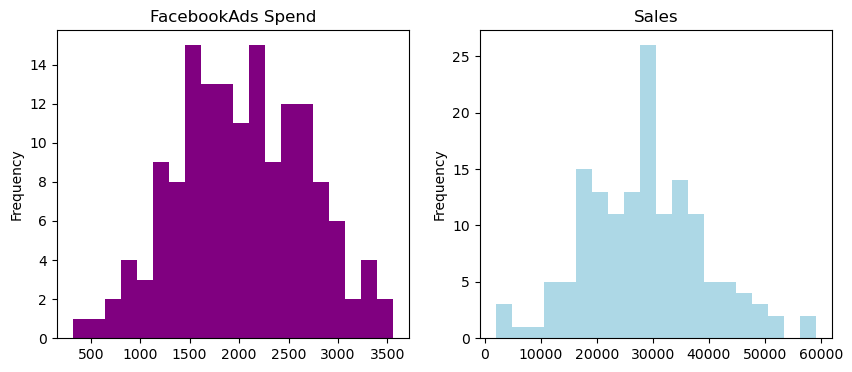

In [85]:
fig, axs = plt.subplots(1,2, figsize=(10,4))
df["FacebookAds"].plot(kind="hist", bins=20, color="purple", title= "FacebookAds Spend", ax=axs[0])
df["Sales"].plot(kind="hist", bins=20, color="lightblue", title= "Sales", ax=axs[1])
plt.show()

## Simple Linear Regression Model

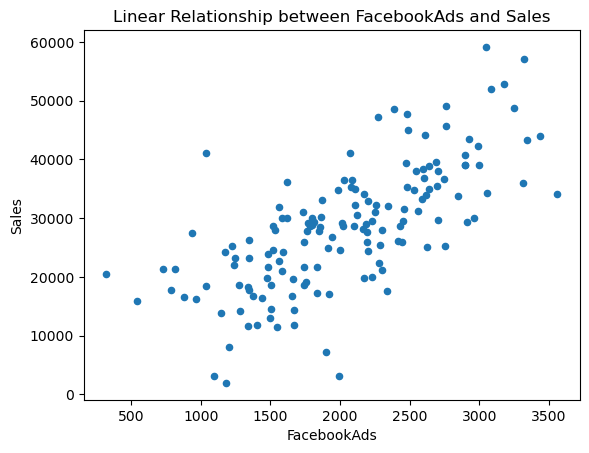

In [60]:
#  Checking linearity
df.plot(kind="scatter", x="FacebookAds", y="Sales")
plt.title("Linear Relationship between FacebookAds and Sales")
plt.xlabel("FacebookAds")
plt.ylabel("Sales")
plt.show()

အထက်ပါပုံကို ကြည့်လျှင် Facebook ကြော်ငြာအသုံးစရိတ် (FacebookAds) နှင့် ရောင်းအား (Sales) တို့သည် မျဉ်းဖြောင့်ပုံစံ အပေါင်းဆက်စပ်မှုရှိသည်ကို အကြမ်းဖျင်းတွေ့မြင်ရသဖြင့် မျဉ်းဖြောင့်ဆက်သွယ်မှုပုံစံကို အသုံးပြုပါက သင့်လျော်သည်ဟု ယူဆနိုင်ပါသည်။

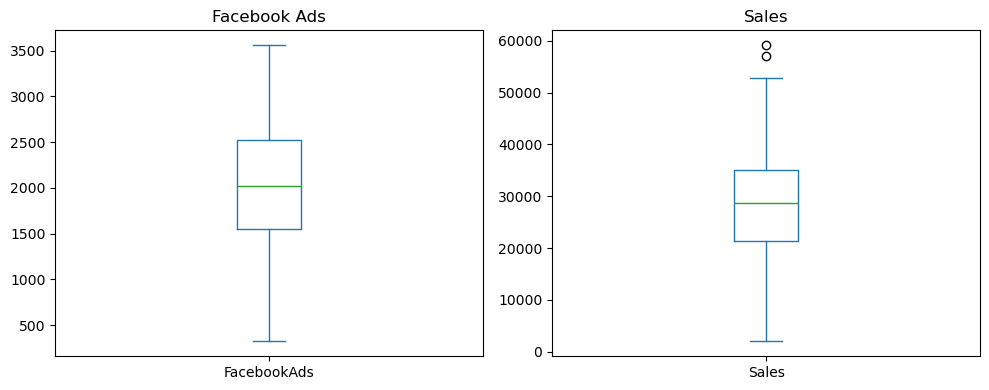

In [61]:
# Checking outliers
fig, axs=plt.subplots(1,2, figsize=(10,4))
df["FacebookAds"].plot(kind="box", ax=axs[0], title="Facebook Ads")
df["Sales"].plot(kind="box", ax=axs[1], title="Sales")
plt.tight_layout()
plt.show()

အထက်ပါပုံကိုကြည့်လျှင် ရောင်းအား (Sales) ကော်လံတွင် အစွန်းရောက်တန်ဖိုးများ(Outliers) ပါနေသည်ကို တွေ့မြင်နိုင်ပါသည်။

In [62]:
# Function to remove outliers using IQR
def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    cleaned_df = data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]
    return cleaned_df, lower_bound, upper_bound

# Remove outliers for both columns
df_cleaned, sales_lower, sales_upper = remove_outliers_iqr(df, "Sales")

print("IQR Outlier Bounds:")
print(f"Sales: {sales_lower:.2f}, {sales_upper:.2f}")

print("Before:", df.shape)
print("After removing outliers:", df_cleaned.shape)

IQR Outlier Bounds:
Sales: 613.96, 55693.91
Before: (150, 2)
After removing outliers: (148, 2)


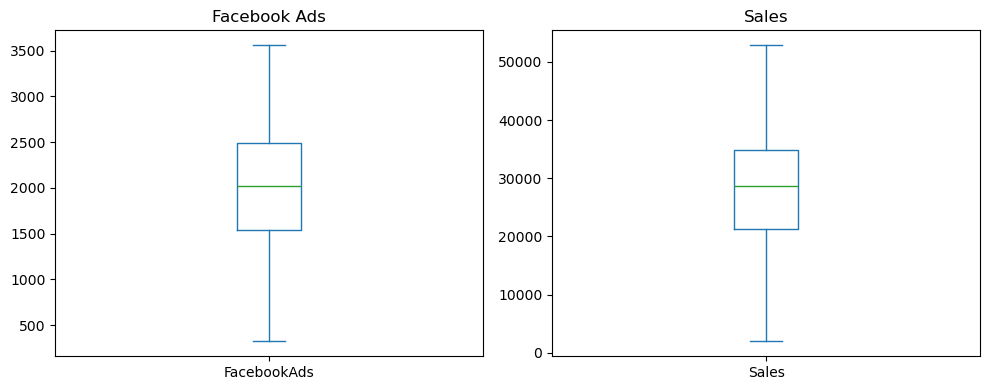

In [63]:
# Checking outliers
fig, axs=plt.subplots(1,2, figsize=(10,4))
df_cleaned["FacebookAds"].plot(kind="box", ax=axs[0], title="Facebook Ads")
df_cleaned["Sales"].plot(kind="box", ax=axs[1], title="Sales")
plt.tight_layout()
plt.show()

In [64]:
# Computing the Pearson's Correlation Coefficient
import scipy.stats as sc
r = sc.pearsonr(df_cleaned["FacebookAds"], df_cleaned["Sales"])
print("Pearson r = ", round(r[0], 4), "with p-value = ", round(r[1], 4))

Pearson r =  0.6897 with p-value =  0.0


အထက်ပါအဖြေအရ ဆက်စပ်မှုပြကိန်းတန်ဖိုး r=0.6897 ဖြစ်၍ FacebookAds နှင့် Sales တို့၏ ဆက်စပ်မှုဒီဂရီမှာ ကောင်းမွန်သည်ဟု ယူဆနိုင်ပါသည်။

In [65]:
# Fitting the Regression Model
import statsmodels.formula.api as smf
model = smf.ols("Sales~FacebookAds", data=df_cleaned, missing="drop").fit()

In [76]:
# Getting the model parameters
print(f"Model parameters:\n {model.params}")

Model parameters:
 Intercept      6038.287987
FacebookAds      10.919593
dtype: float64


In [67]:
# Getting the model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.476
Model:                            OLS   Adj. R-squared:                  0.472
Method:                 Least Squares   F-statistic:                     132.4
Date:                Sun, 30 Nov 2025   Prob (F-statistic):           3.23e-22
Time:                        12:05:19   Log-Likelihood:                -1528.4
No. Observations:                 148   AIC:                             3061.
Df Residuals:                     146   BIC:                             3067.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept    6038.2880   2011.031      3.003      

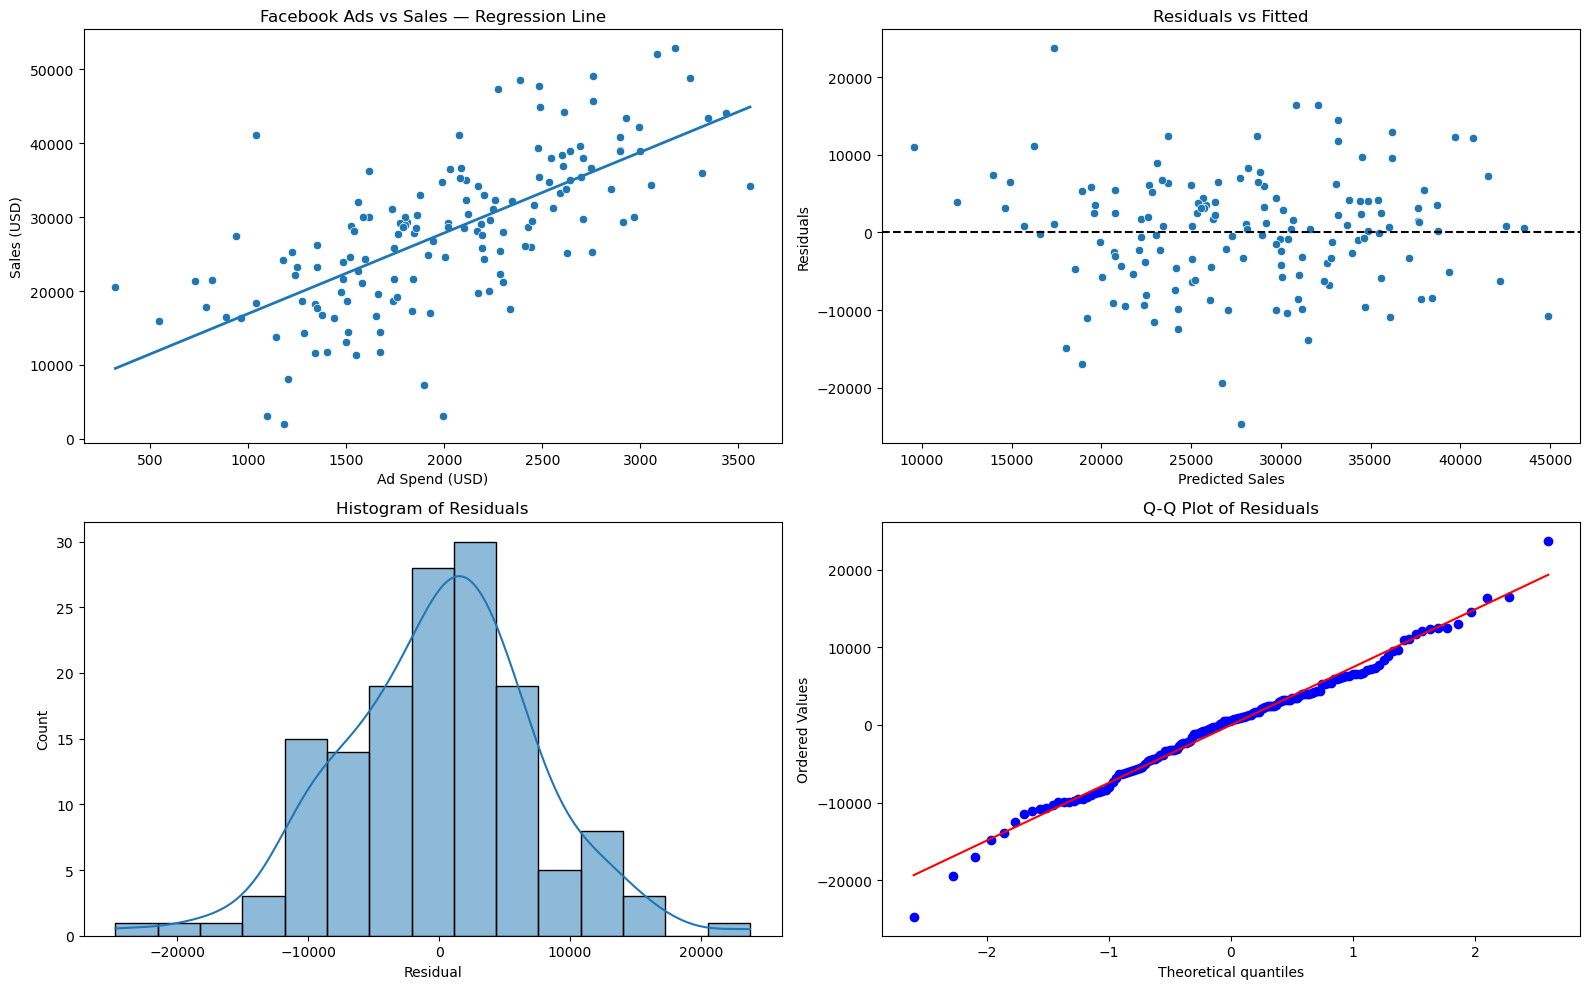

In [86]:
# FACEBOOK ADS vs SALES — FULL SIMPLE LINEAR REGRESSION
# -----------------------------------------------------

# Extract predictions & residuals
# -----------------------------------
df_cleaned["Predicted"] = model.predict(X)
df_cleaned["Residuals"] = df_cleaned["Sales"] - df_cleaned["Predicted"]

# (2,2) SUBPLOTS GRID
# --------------------------------
fig, axs = plt.subplots(2,2, figsize=(16,10))

# 1. Plot Regression Line
# --------------------------------
sns.scatterplot(x="FacebookAds", y="Sales", ax=axs[0,0], data=df_cleaned)
sns.lineplot(x="FacebookAds", y="Predicted", ax=axs[0,0], data=df_cleaned, linewidth=2)
axs[0,0].set_title("Facebook Ads vs Sales — Regression Line")
axs[0,0].set_xlabel("Ad Spend (USD)")
axs[0,0].set_ylabel("Sales (USD)")

# --------------------------------
# 2. Residual Plot (Check Linearity)
sns.scatterplot(x=df_cleaned["Predicted"], y=df_cleaned["Residuals"], ax=axs[0,1])
axs[0,1].axhline(0, color='black', linestyle='--')
axs[0,1].set_title("Residuals vs Fitted")
axs[0,1].set_xlabel("Predicted Sales")

# 3. Histogram of Residuals (Normality)
# --------------------------------
sns.histplot(df_cleaned["Residuals"], kde=True, bins=15, ax=axs[1,0])
axs[1,0].set_title("Histogram of Residuals")
axs[1,0].set_xlabel("Residual")

# 4. Q-Q Plot (Normality Check)
# -------------------------------
from scipy.stats import probplot

probplot(df_cleaned["Residuals"], dist="norm", plot=axs[1,1])
axs[1,1].set_title("Q-Q Plot of Residuals")

# ----------------------------------------
plt.tight_layout()
plt.show()

### OLS Regression ရလဒ်များ အဓိပ္ပာယ်ဖွင့်ဆိုချက်

Facebook ကြော်ငြာစရိတ် (Facebook Ad Spend) နှင့် အရောင်း (Sales) အကြား ဆက်နွယ်မှုကို လေ့လာထားသော OLS Regression Summary ကို အခြေခံ၍ အဓိက တွေ့ရှိချက်များမှာ အောက်ပါအတိုင်း ဖြစ်ပါသည် (လေ့လာချက်ပေါင်း $N=148$):

#### ၁။ မော်ဒယ် စွမ်းဆောင်ရည် ($R^2$)
* **$R^2$: $0.476$**
    * ဤမော်ဒယ်သည် စုစုပေါင်း အရောင်းပြောင်းလဲမှု၏ **၄၇.၆%** ကို Facebook Ads မှတစ်ဆင့် ရှင်းပြနိုင်ပါသည်။
    * **ကောက်ချက်:** ၎င်းသည် **အသင့်အတင့် ခိုင်မာသော ဆက်နွယ်မှု** ကို ပြသပြီး၊ ကြော်ငြာစရိတ်သည် အရောင်း၏ အဓိက မောင်းနှင်အား (Key Driver) ဖြစ်နေသော်လည်း၊ ကျန်ရှိသော ၅၂.၄% ကို အခြားသော လုပ်ငန်းဆိုင်ရာ အကြောင်းအရင်းများ (ဥပမာ- ဈေးနှုန်း၊ ကုန်ပစ္စည်းအရည်အသွေး) မှ လွှမ်းမိုးနေကြောင်း သိရှိရပါသည်။

#### ၂။ Coefﬁcients များနှင့် စီးပွားရေးဆိုင်ရာ သက်ရောက်မှု
| Variable (ကိုယ်စားပြုပြောင်းလဲဖော်) | Coefﬁcient (အကျိုးသက်ရောက်မှု) | P-Value (သိသာထင်ရှားမှု) | အဓိပ္ပာယ်ဖွင့်ဆိုချက် |
| :--- | :--- | :--- | :--- |
| **Intercept (အမြဲတမ်းတန်ဖိုး)** | **6038.29** | **0.003** | **အခြေခံအရောင်း (Baseline Sales):** ကြော်ငြာစရိတ် လုံးဝမသုံးစွဲသည့်တိုင် ရရှိနိုင်သည့် ပျမ်းမျှ အရောင်းပမာဏမှာ **၆,၀၃၈ ယူနစ်** ဖြစ်သည်။ |
| **FacebookAds** | **10.92** | **0.000** | **ရင်းနှီးမြှုပ်နှံမှု အကျိုးအမြတ် (ROI):** Facebook Ads စရိတ် **၁ ယူနစ်** တိုးလာတိုင်း၊ အရောင်းပမာဏသည် ပျမ်းမျှအားဖြင့် **၁၀.၉၂ ယူနစ်** တိုးတက်လာပါသည်။ |

#### ၃။ စာရင်းအင်းဆိုင်ရာ မှန်ကန်မှု စစ်ဆေးခြင်း
* **စာရင်းအင်း သိသာထင်ရှားမှု:** **Prob (F-statistic)** တန်ဖိုးသည် အလွန်နည်းပါးသောကြောင့် (Effectively $0.000$) ဤမော်ဒယ်သည် **ယုံကြည်စိတ်ချရမှု** ရှိကြောင်း အတည်ပြုနိုင်ပါသည်။
* **Residuals များ ပုံမှန်ဖြန့်ဝေမှု (Normality of Residuals):**
    * **Prob(Jarque-Bera): 0.169**
    * P-value သည် $0.05$ ထက် မြင့်မားသောကြောင့် Error များသည် **ပုံမှန် ဖြန့်ဝေမှု (Normal Distribution)** ကို လိုက်နာပါသည်။ ၎င်းသည် OLS ၏ အဓိကယူဆချက်ကို ပြည့်မီသောကြောင့် Coefﬁcient များ၏ P-value များသည် **မှန်ကန်ပြီး ယုံကြည်စိတ်ချရ** ပါသည်။
* **Durbin-Watson:** **1.781** (၂ နီးစပ်) သည် Residuals များကြားတွင် ဆက်စပ်မှု (Autocorrelation) မရှိသလောက် နည်းပါးကြောင်း ပြသသည်။

#### အဓိက ကောက်ချက်
ဤခွဲခြမ်းစိတ်ဖြာချက်သည် Facebook ကြော်ငြာစရိတ်သည် လုပ်ငန်း၏ အရောင်းရရှိမှုအပေါ် **ခိုင်မာပြီး သိသာထင်ရှားသော** သက်ရောက်မှုရှိကြောင်း သက်သေပြပါသည်။ စာရင်းအင်းအရ ယုံကြည်စိတ်ချရသော ဤမော်ဒယ်သည် ကြော်ငြာစရိတ်ကို ထိရောက်စွာ အသုံးပြုခြင်းဖြင့် **၁၀.၉ ဆ** နီးပါး အကျိုးအမြတ် ပြန်ရနိုင်ကြောင်း ညွှန်ပြလျက်ရှိပါသည်။

### မော်ဒယ် အနှစ်ချုပ်နှင့် အဓိက ထိုးထွင်းသိမြင်မှုများ

Facebook ကြော်ငြာစရိတ်နှင့် အရောင်းပမာဏအပေါ် Simple Linear Regression ခွဲခြမ်းစိတ်ဖြာချက်များအရ အောက်ပါအတိုင်း တွေ့ရှိရပါသည်-

* **မော်ဒယ် လွှမ်းမိုးမှု:** အရောင်း ပြောင်းလဲမှု၏ **၄၇.၆%** ကို ကြော်ငြာစရိတ်က ရှင်းပြနိုင်ပါသည်။
* **စီးပွားရေး အကျိုးအမြတ် (ROI):** ကြော်ငြာစရိတ် **၁ ယူနစ်** တိုးမြှင့်ပါက အရောင်းသည် **၁၀.၉၂ ယူနစ်** တိုးတက်လာပါသည်။ (အလွန်သိသာထင်ရှားသည် $p < 0.001$).
* **အခြေခံ အရောင်း:** ကြော်ငြာမပါဘဲ ရရှိနိုင်သည့် အခြေခံ အရောင်းပမာဏမှာ **၆,၀၃၈ ယူနစ်** ဖြစ်ပါသည်။
* **မော်ဒယ် ခိုင်မာမှု:** Residuals များသည် ပုံမှန်ဖြန့်ဝေမှု (Normality) ကို ပြည့်မီသောကြောင့် (Jarque-Bera $p=0.169$) ရလဒ်များသည် ယုံကြည်စိတ်ချရပါသည်။